# Rerouting Paths to Avoid Flooding 
**Sofia Sarak**

The following code builds a function that helps avoid flooding events when routing within the Amazon rainforest. The pipeline incorporates river location, seasonality, and road networks when developing routes.

### Data Sources
- **Road geometries:** OpenStreetMap (OSM) and PrevisIA, provided by AmazoniaHack 4.0 team
- **River geometries:** [Fundação Brasileira para o Desenvolvimento Sustentável](https://geo.fbds.org.br/PA/PARAGOMINAS/HIDROGRAFIA/), for the Paragominas region
- **Test pairs:** Start and end points to test for routing (provided by AmazoniaHack 4.0)

### Background information
- On Paragominas precipiation: [WeatherSpark](https://weatherspark.com/y/30245/Average-Weather-in-Paragominas-Par%C3%A1-Brazil-Year-Round)
- On flooding in the Amazon generally: [WWF](https://wwf.panda.org/discover/knowledge_hub/where_we_work/amazon/about_the_amazon/ecosystems_amazon/floodplain_forests/)

## Setup

In [1]:
# load in necessary libraries
import os
import pandas as pd
import geopandas as gpd
from pyprojroot import here
import matplotlib.pyplot as plt
import networkx as nx
from math import radians, sin, cos, sqrt, atan2
from scipy.spatial import KDTree
import numpy as np
from shapely.geometry import LineString

In [2]:
# read in data
osm_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-osm-paragominas.geojson")) # OSM roads
previsia_roads = gpd.read_file(here("challenge-docs/challenge-3/roads-previsia-2025-paragominas.geojson")) # remotely-sensed roads
rivers = gpd.read_file(here("my-data/para/PA_1505502_RIOS_SIMPLES.shp")).set_crs("EPSG:31983").to_crs(osm_roads.crs) # river network
test = pd.read_csv(here("challenge-docs/challenge-3/test-pairs.csv")) # test pairs provided by hackathon

In [3]:
# same crs?
assert osm_roads.crs == previsia_roads.crs
assert rivers.crs == osm_roads.crs
print(osm_roads.crs)

EPSG:4326


In [4]:
# save test pairs as geo
test_pairs = test.assign( # iterate across appropriate columns and create points
    origin=list(zip(test.origin_lon, test.origin_lat)),
    dest=list(zip(test.dest_lon, test.dest_lat)))

In [5]:
# filter for OSM roads that are accessible by vehicle (as per AmazoniaHack instructions)
osm_roads_f = osm_roads[~osm_roads['highway'].isin(['track', 'path', 'footway', 'service'])]

## Step 1: Build a pipeline to find the shortest route distance using OSM

In [6]:
# haversine distance function (as the crow flies) -- helper function
def haversine(u, v):
    lon1, lat1 = u
    lon2, lat2 = v
    R = 6371000  # meters
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

In [7]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())


In [8]:
nodes = list(G.nodes())
tree = KDTree(nodes)

def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist  # now returns distance too

results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        path = nx.shortest_path(G, source=source, target=target, weight='weight')
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        path, length = None, None
    results.append({
        'id': row.id, 'path': path, 'road_distance_m': length,
        'origin_snap_deg': source_dist, 'dest_snap_deg': target_dist
    })

osm_results_df = pd.DataFrame(results)

# convert dest snap to meters
osm_results_df['dest_snap_m'] = osm_results_df['dest_snap_deg'] * 111000

osm_results_df

,id,path,road_distance_m,origin_snap_deg,dest_snap_deg,dest_snap_m
0,par-01,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",47046.634780,0.000214,0.023558,2614.905576
1,par-02,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",64585.638900,0.000214,0.028618,3176.622234
2,par-03,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",61375.744609,0.000214,0.031455,3491.463331
3,par-04,None,NaN,0.000214,0.050589,5615.349448
4,par-05,None,NaN,0.000214,0.050630,5619.894718
5,par-06,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",110433.783646,0.000214,0.022733,2523.345568
6,par-07,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",66855.786671,0.000214,0.028818,3198.852427
7,par-08,None,NaN,0.000214,0.054815,6084.453462
8,par-09,None,NaN,0.000214,0.055747,6187.959412
9,par-10,None,NaN,0.000214,0.050668,5624.107730


**Result:** Our pipeline recognized that 7 of the 16 pairs have adequate routes from start to finish. Of these, 1 or 2 are within reasonable walking distance (~2.5km). This matches the conditions that AmazoniaHack had provided.


## Step 2: Integrate river geometries into workflow

We will penalize routes that intersect with river geometries.

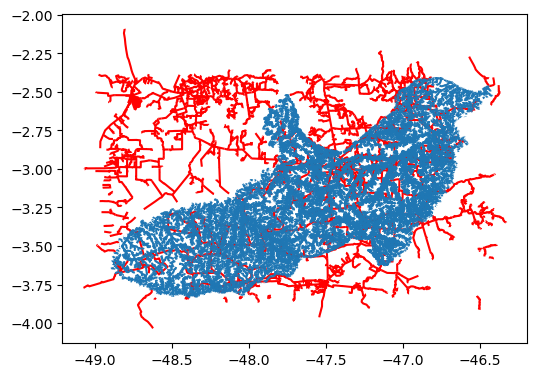

In [9]:
# plot OSM roads and river to ensure geographic match
fig, ax = plt.subplots(figsize = (6, 6))
# previsia_roads.plot(ax=ax,
#                     color = 'red')
osm_roads.plot(ax=ax,
              color = "red")
rivers.plot(ax=ax)

plt.show()

In [10]:
# Find road segments that intersect any river
crossings = gpd.sjoin(osm_roads_f, rivers, predicate="intersects", how="inner")
print(len(crossings), "road segments cross a river")

1629 road segments cross a river


One of the few things we from the OSM road data is their surface. We will assume that paved roads are safer than unpaved roads, when they cross rivers.

In [11]:
# denote which surfaces are safe and unsafe
safe_surfaces = ['asphalt', 'paved', 'concrete']
risky_surfaces = ['unpaved', 'gravel', 'dirt', 'ground', 'sand', 'track']
unknown = crossings['surface'].isna()

# add a column for risk based on surface
crossings['risk'] = 'unknown'
crossings.loc[crossings['surface'].isin(safe_surfaces), 'risk'] = 'safe'
crossings.loc[crossings['surface'].isin(risky_surfaces), 'risk'] = 'risky'

# quantify penalty (route will not be chosen if road is too risky)
penalty_map = {'safe': 1, 'unknown': 3, 'risky': 8}

### Apply surface/river penalty to OSM roads

In [12]:
# initialize empty graph
G = nx.Graph()

# create nodes
for _, row in osm_roads_f.iterrows(): # loop over every road
    coords = list(row.geometry.coords) # extract line coordinates and save as tuples
    
    # iterate through coords
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

nodes = list(G.nodes())
tree = KDTree(nodes)

# define snapping
def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist

# get the crossing point geometry for each crossing
crossings['crossing_point'] = crossings.apply(
    lambda row: row.geometry.intersection(rivers.loc[row.index_right].geometry),
    axis=1
)

# snap each crossing point to the nearest node in G
crossings['nearest_node'] = crossings['crossing_point'].apply(
    lambda pt: snap((pt.x, pt.y))[0] if pt.geom_type == 'Point' else None
)

# determine risk tier per crossing (from surface, as before)
penalty_map = {'safe': 1, 'unknown': 3, 'risky': 8}
crossings['penalty'] = crossings['risk'].map(penalty_map)

# calculate a base penalty weight (with no penalty)
for u, v, data in G.edges(data=True):
    if 'base_weight' not in data:
        data['base_weight'] = data['weight']

# add on penalty to base weigh
for _, row in crossings.dropna(subset=['nearest_node']).iterrows():
    node = row['nearest_node']
    for neighbor in G.neighbors(node):
        G[node][neighbor]['weight'] = G[node][neighbor]['base_weight'] * row['penalty']

### Compare routes before and after penalty

In [13]:
# BASELINE: no penalties 
G_base = nx.Graph()
for _, row in osm_roads_f.iterrows():
    coords = list(row.geometry.coords)
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G_base.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

nodes_base = list(G_base.nodes())
tree_base = KDTree(nodes_base)
def snap_base(point):
    dist, idx = tree_base.query(point)
    return nodes_base[idx], dist

baseline_results = []
for _, row in test_pairs.iterrows():
    source, _ = snap_base(row.origin)
    target, _ = snap_base(row.dest)
    try:
        length = nx.shortest_path_length(G_base, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        length = None
    baseline_results.append({'id': row.id, 'baseline_distance_m': length})

baseline_df = pd.DataFrame(baseline_results)

# PENALIZED: G with river penalties already applied
penalized_results = []
for _, row in test_pairs.iterrows():
    source, _ = snap(row.origin)
    target, _ = snap(row.dest)
    try:
        length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        length = None
    penalized_results.append({'id': row.id, 'penalized_cost': length})

penalized_df = pd.DataFrame(penalized_results)

# COMPARE 
comparison = baseline_df.merge(penalized_df, on='id')
comparison['diff_m'] = comparison['penalized_cost'] - comparison['baseline_distance_m']
comparison

,id,baseline_distance_m,penalized_cost,diff_m
0,par-01,47046.634780,47448.240416,401.605636
1,par-02,64585.638900,82613.807287,18028.168387
2,par-03,61375.744609,62064.103377,688.358768
3,par-04,NaN,NaN,NaN
4,par-05,NaN,NaN,NaN
5,par-06,110433.783646,152905.611188,42471.827541
6,par-07,66855.786671,85485.530206,18629.743535
7,par-08,NaN,NaN,NaN
8,par-09,NaN,NaN,NaN
9,par-10,NaN,NaN,NaN


**Result:** Adding the rain/flooding penalty increased the distance – or more accurately, the cost – of routes that crossed rivers. The difference in cost (which is equivalent to traveling that many extra meters) ranges from 401 to 42471.
## Step 3: Integrate rivers, OSM, and PrevisIA into one pipeline

But end up confirming that PrevisIA does not currently work for our purposes.

In [14]:
# build a graph like we did with the OSM roads, this time with PrevisIA
G_prev = nx.Graph()
for _, row in previsia_roads.iterrows():
    coords = list(row.geometry.coords)
    for i in range(len(coords) - 1):
        u, v = coords[i], coords[i+1]
        G_prev.add_edge(u, v, weight=haversine(u, v))

In [15]:
# comvine OSM and PrevisIA graphs
G_combined = nx.compose(G, G_prev) 

# add nodes based on a tolerance, connecting the two different graphs
prev_components = list(nx.connected_components(G_prev))
osm_nodes = np.array(list(G.nodes()))
prev_nodes = np.array(list(G_prev.nodes()))
osm_tree = KDTree(osm_nodes)
tolerance_deg = 150 / 111000

for comp in prev_components:
    comp_arr = np.array(list(comp))
    dists, idxs = osm_tree.query(comp_arr)
    min_i = dists.argmin()
    if dists[min_i] < tolerance_deg:
        p_node = tuple(comp_arr[min_i])
        o_node = tuple(osm_nodes[idxs[min_i]])
        G_combined.add_edge(p_node, o_node, weight=dists[min_i] * 111000)

In [16]:
# repeat same routing pipeline is before, now with combined OSM and PrevisIA data
nodes = list(G_combined.nodes())
tree = KDTree(nodes)
def snap(point):
    dist, idx = tree.query(point)
    return nodes[idx], dist

comb_results = []
for _, row in test_pairs.iterrows():
    source, source_dist = snap(row.origin)
    target, target_dist = snap(row.dest)
    try:
        penalized_length = nx.shortest_path_length(G_combined, source=source, target=target, weight='weight')
    except nx.NetworkXNoPath:
        penalized_length = None
    try:
        base_length = nx.shortest_path_length(G_combined, source=source, target=target, weight='base_weight')
    except nx.NetworkXNoPath:
        base_length = None
    comb_results.append({
        'id': row.id,
        'base_distance_m': base_length,
        'penalized_distance_m': penalized_length,
        'diff_m': (penalized_length - base_length) if (base_length is not None and penalized_length is not None) else None
    })

comb_df = pd.DataFrame(comb_results)

# view
comb_df

,id,base_distance_m,penalized_distance_m,diff_m
0,par-01,43656.906382,45308.158251,1651.251869
1,par-02,67075.269306,92890.809377,25815.540071
2,par-03,NaN,NaN,NaN
3,par-04,NaN,NaN,NaN
4,par-05,NaN,NaN,NaN
5,par-06,NaN,NaN,NaN
6,par-07,NaN,NaN,NaN
7,par-08,NaN,NaN,NaN
8,par-09,NaN,NaN,NaN
9,par-10,NaN,NaN,NaN


**Result:** When integrating PrevisIA data, only two test pairs are actually routed paths. This is most likely due to our method of processing the PrevisIA data (particularly because the AmazoniaHack team noted that they were able to get 9 pairs to route properly). It is likely that it resulted in a lot of gaps that our buffer of 150km does not resolve.

Because of the time constraints of this competition, we cannot explore this further.

## Step 4: Incorporate seasonality and add nuance based on location

*Due to weak results in Step 3, we will continue with using only OSM geometries.*

Wet and dry seasons change how risky a river crossing can be, so we will alter our weighting to account for this.

Some sources suggest that flooding is worse in north of Amazon, above the equator ([WWF](https://wwf.panda.org/discover/knowledge_hub/where_we_work/amazon/about_the_amazon/ecosystems_amazon/floodplain_forests/)). However, there is a lot of nuiance in Amazonian precipiation (outside of north and south), so it is recommended that this operation gets split up based on subregions. For our small-scale example of Paragominas, we will be using information from [WeatherSpark](https://weatherspark.com/y/30245/Average-Weather-in-Paragominas-Par%C3%A1-Brazil-Year-Round).

In the future, recent rainfall can/should replace month of year. Increase road risk based on the amount of precipitation to anticipate flooding.

In [17]:
# determine passability based on month and location
def check_passability(month, location):

# is location Paragominas? (the only region we have integrated data on)
    if location == "Paragominas":

# built penalty weighting based on month of the year
        if month in ['January', 'February', 'May']:
            penalty_map = {'safe': 2, 'unknown': 4, 'risky': 9}
        elif month in ['March', 'April']:
            penalty_map = {'safe': 3, 'unknown': 5, 'risky': 10}
        else:
            penalty_map = {'safe': 1, 'unknown': 3, 'risky': 5}
        return penalty_map
    
    else:
        print("No rainfall information on this region at this time")

In [18]:
# built function to route based on rivers and weather 
def route_for_month(G, crossings, test_pairs, month, location):

# temporary check while Paragominas is the only location
    if location == "Paragominas":

    # built graph within function
        G_base = nx.Graph()
        for _, row in osm_roads_f.iterrows():
            coords = list(row.geometry.coords)
        for i in range(len(coords) - 1):
            u, v = coords[i], coords[i+1]
            G_base.add_edge(u, v, weight=haversine(u, v), **row.drop("geometry").to_dict())

        nodes = list(G.nodes())
        tree = KDTree(nodes)
        def snap(point):
            dist, idx = tree.query(point)
            return nodes[idx], dist

        penalty_map = check_passability(month, location)
        crossings['penalty'] = crossings['risk'].map(penalty_map)

# base weight
        for u, v, data in G.edges(data=True):
            if 'base_weight' not in data:
                data['base_weight'] = data['weight']

# adding penalty to weight
        for _, row in crossings.dropna(subset=['nearest_node']).iterrows():
            node = row['nearest_node']
            for neighbor in G.neighbors(node):
                G[node][neighbor]['weight'] = G[node][neighbor]['base_weight'] * row['penalty']

        results = []
        for _, row in test_pairs.iterrows():
            source, source_dist = snap(row.origin)
            target, target_dist = snap(row.dest)
            try:
                base_path = nx.shortest_path(G, source=source, target=target, weight='base_weight')
                base_length = nx.shortest_path_length(G, source=source, target=target, weight='base_weight')
            except nx.NetworkXNoPath:
                base_path, base_length = None, None
            try:
                penalized_path = nx.shortest_path(G, source=source, target=target, weight='weight')
                penalized_length = nx.shortest_path_length(G, source=source, target=target, weight='weight')
            except nx.NetworkXNoPath:
                penalized_path, penalized_length = None, None
            results.append({
                'id': row.id,
                'month': month,
                'base_path': base_path,
                'base_distance_m': base_length,
                'penalized_path': penalized_path,
                'penalized_cost': penalized_length,
                'diff_m': (penalized_length - base_length) if (base_length is not None and penalized_length is not None) else None,
                'dest_snap_m': target_dist * 111000
            })

        return pd.DataFrame(results)

    else:
        return("No seasonal data at this time.")

In [19]:
# testing function: March in Paragominas
route_for_month(G, crossings, test_pairs, 'March', 'Paragominas')

,id,month,base_path,base_distance_m,penalized_path,penalized_cost,diff_m,dest_snap_m
0,par-01,March,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",47046.634780,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",70116.533254,23069.898473,2614.905576
1,par-02,March,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",64585.638900,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",126616.681572,62031.042672,3176.622234
2,par-03,March,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",61375.744609,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",88446.726330,27070.981721,3491.463331
3,par-04,March,None,NaN,None,NaN,NaN,5615.349448
4,par-05,March,None,NaN,None,NaN,NaN,5619.894718
5,par-06,March,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",110433.783646,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",168171.791795,57738.008149,2523.345568
6,par-07,March,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",66855.786671,"[(-47.344771, -2.995234), (-47.34498, -2.99542...",109729.019602,42873.232930,3198.852427
7,par-08,March,None,NaN,None,NaN,NaN,6084.453462
8,par-09,March,None,NaN,None,NaN,NaN,6187.959412
9,par-10,March,None,NaN,None,NaN,NaN,5624.107730


In [20]:
# testing function: December in Acre
route_for_month(G, crossings, test_pairs, 'December', 'Acre')

'No seasonal data at this time.'

## Step 5: Plot route changes to see differences across routes due to seasonality

In [21]:
# built function to plot both penalized and base route
def plot_routes(row, osm_roads_f=None, padding=0.05):
    fig, ax = plt.subplots(figsize=(10, 10))

    if osm_roads_f is not None:
        osm_roads_f.plot(ax=ax, color='lightgray', linewidth=0.5, zorder=1)

    all_coords = []

    if row['base_path']:
        base_line = LineString(row['base_path'])
        gpd.GeoSeries([base_line]).plot(ax=ax, color='blue', linewidth=2, label='Baseline', zorder=2)
        all_coords.extend(row['base_path'])

    if row['penalized_path']:
        pen_line = LineString(row['penalized_path'])
        gpd.GeoSeries([pen_line]).plot(ax=ax, color='red', linewidth=2, linestyle='--', label='Penalized (safe)', zorder=3)
        all_coords.extend(row['penalized_path'])

# change zoom based on location of start and end points
    if all_coords:
        xs = [c[0] for c in all_coords]
        ys = [c[1] for c in all_coords]
        ax.set_xlim(min(xs) - padding, max(xs) + padding)
        ax.set_ylim(min(ys) - padding, max(ys) + padding)

    ax.legend()
    ax.set_title(f"{row['id']} — {row['month']}")
    plt.show()

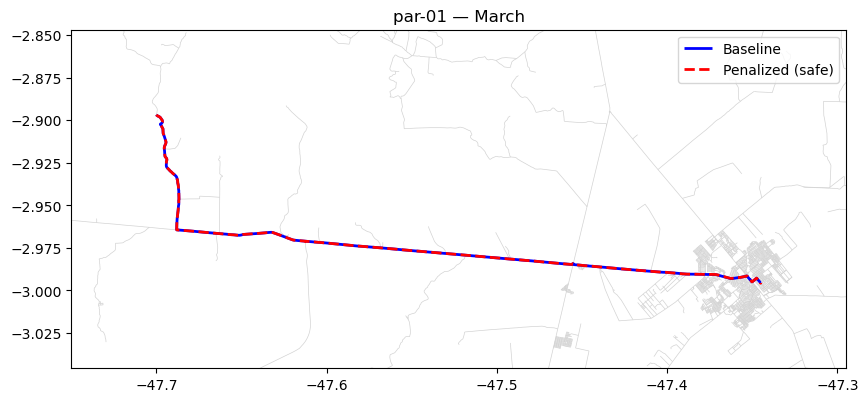

In [37]:
# in order to plot:

# 1. run and save results from route_for_month() function
march_results = route_for_month(G, crossings, test_pairs, 'March', 'Paragominas')

# 2. specify which pair/route you are interested in
row = march_results[march_results.id == 'par-01'].iloc[0]

# 3. plot, with the OSM base roads in gray 
plot_routes(row, osm_roads_f)

**Result:** Test pair par-06 had the biggest route shift in March – one of the wettest seasons in Paragominas. Hopefully, this means that our function helps provide a safer and more efficient route for Amazon workers.

## Step 6: Calculate impact

For each month of the year, we will calculate how many times the penalized route actually diverges from the baseline route. This statistic – how many times our function reroutes a path based on rain, in a year – quantifies product impact.

In [26]:
def count_divergence_by_month(G, crossings, test_pairs, months, location):
    divergence_counts = []

    for month in months:
        month_df = route_for_month(G, crossings, test_pairs, month, location)

        # only consider pairs where BOTH paths exist (drop unreachable)
        valid = month_df.dropna(subset=['base_path', 'penalized_path'])

        diverged = valid.apply(lambda row: row['base_path'] != row['penalized_path'], axis=1)

        divergence_counts.append({
            'month': month,
            'total_valid_pairs': len(valid),
            'diverged_count': diverged.sum(),
            'diverged_pct': (diverged.sum() / len(valid) * 100) if len(valid) > 0 else None
        })

    return pd.DataFrame(divergence_counts)

In [27]:
all_months = ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December']

divergence_df = count_divergence_by_month(G, crossings, test_pairs, all_months, 'Paragominas')

overall_diverged_pct = divergence_df['diverged_count'].sum() / divergence_df['total_valid_pairs'].sum() * 100
print(overall_diverged_pct)

88.09523809523809


In [29]:
divergence_df

,month,total_valid_pairs,diverged_count,diverged_pct
0,January,7,6,85.714286
1,February,7,6,85.714286
2,March,7,7,100.000000
3,April,7,7,100.000000
4,May,7,6,85.714286
5,June,7,6,85.714286
6,July,7,6,85.714286
7,August,7,6,85.714286
8,September,7,6,85.714286
9,October,7,6,85.714286


In [36]:
row = march_results[march_results.id == 'par-01'].iloc[0]
print(row['base_path'] == row['penalized_path'])
print(len(row['base_path']), len(row['penalized_path']))

False
483 481




That concludes this notebook! As a recap, we:
- routed paths between the provided start and end points using OSM data,
- confirmed that the PrevisaIA data resulted in a lot of loose ends – not feasible to address in this specific project,
- created a workflow that penalizes routing based on the presence of a river crossing, AND
- altered this penalty based on road surface as well as the season that the route is being requested in.

Though this code did not develop a complete product, I hope that some of the logic and thinking behind it can still help inform future routing efforts for those protecting the Rainforest. Thank you!